## **P2: Importing Dataset & Data Wrangling**

Using GEO ((Gene Expression Omnibus) dataset GSE13164 for leukemia diagnosis, includes:
- Downloading and parsing GEO series data
- Extracting and filtering labels
- Merging sample expression data
- Mapping probes to gene accessions
- Aligning and encoding the final dataset

### **Import Required Libraries**

Load all necessary libraries for data processing:
- **GEOparse**: To access to sample metadata, expression data, and platform information.
- **pandas (pd)**: To create DataFrames, merge tables, and handle CSV input/output.
- **numpy (np)**: For array operations and mathematical functions.
- **LabelEncoder (from sklearn.preprocessing)**: To convert categorical labels (leukemia types) into numeric codes for machine learning models.
- **re**: To identify leukemia types in sample characteristics using regex search.
- **os**: To create directories and manage file paths.
- **reduce (from functools)**: To merge multiple DataFrames sequentially.

In [1]:
import GEOparse
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import re 
import os 
from functools import reduce

### **Configuration and Constants**
Set up configuration parameters including the GEO dataset ID, output file names, target disease classes, and feature identifier column.

In [2]:
# configuration
GSE_ID = "GSE13164" 
OUTPUT_CLEAN_DATA = "GSE13164_cleaned_features.csv"
OUTPUT_CLEAN_LABELS = "GSE13164_cleaned_labels.csv"

# constants
TARGET_CLASSES = ['ALL', 'AML', 'CLL', 'CML']
FEATURE_IDENTIFIER = 'GB_ACC'

### **Download and Parse GEO Data**

Downloads the GEO dataset using GEOparse and extracts the platform (GPL) annotation table. Returns both the GEO object (containing sample data) and the platform table (containing probe annotations).

In [3]:
def download_and_parse_geo(gse_id):
    print(f"Downloading and parsing GEO series: {gse_id}...")
    print(f"Current working directory: {os.getcwd()}")
    
    try:
        # Try to load from local Raw Data folder first if it exists
        local_file = f"./Raw Data/{gse_id}_family.soft.gz"
        print(f"Checking for local file at: {local_file}")
        print(f"Local file exists: {os.path.exists(local_file)}")
        
        if os.path.exists(local_file):
            print(f"Loading GEO data from local file: {local_file}")
            gse = GEOparse.get_GEO(filepath=local_file, silent=False)
        else:
            print(f"Local file not found, attempting FTP download...")
            gse = GEOparse.get_GEO(geo=gse_id, destdir="./", silent=False)
    except Exception as e:
        print(f"Error downloading/parsing {gse_id}: {e}")
        return None, None
    
    platform_key = list(gse.gpls.keys())[0]
    gpl_table = gse.gpls[platform_key].table.copy()
    
    return gse, gpl_table

### **Extract and Filter Samples**
Iterates through all samples in the GEO dataset and:
- Extracts leukemia type labels from sample characteristics
- Filters for only target classes (ALL, AML, CLL, CML)
- Extracts expression values for valid samples
- Returns filtered sample DataFrames and metadata

In [4]:
def extract_and_filter_samples(gse):
    metadata_list = []
    sample_dfs = []

    for name, gsm in gse.gsms.items():
        characteristics = ' '.join(gsm.metadata.get('characteristics_ch1', ['']))
        leukemia_type = None
        
        # identify leukemia type based on target classes
        for t_type in TARGET_CLASSES:
            if re.search(r'\b' + re.escape(t_type) + r'\b', characteristics, re.IGNORECASE):
                leukemia_type = t_type
                break

        # only process samples belonging to target classes
        if leukemia_type in TARGET_CLASSES:
            metadata_list.append({'Sample_ID': name, 'Leukemia_Type': leukemia_type})
            
            # extract expression data
            gsm_df = gsm.table.copy()
            
            if 'ID_REF' not in gsm_df.columns:
                print(f"Warning: GSM {name} missing 'ID_REF'. Skipping.")
                continue
            
            # identify expression val col
            value_col = next((col for col in gsm_df.columns if col.upper() in ['VALUE', 'LOG_RATIO', 'SIGNAL', 'AVG_SIGNAL', 'NORMALIZED_SIGNAL']), None)
            
            if not value_col:
                non_id_cols = [c for c in gsm_df.columns if c != 'ID_REF']
                if non_id_cols:
                    value_col = non_id_cols[-1]
                else:
                    print(f"Warning: GSM {name} has no detectable value column. Skipping.")
                    continue

            gsm_df = gsm_df[['ID_REF', value_col]].rename(columns={value_col: name})
            sample_dfs.append(gsm_df)

    metadata_df = pd.DataFrame(metadata_list)
    print(f"Samples identified and labeled: {len(sample_dfs)}.")
    
    return sample_dfs, metadata_df

### **Merge Expression Data**
Combines all individual sample DataFrames into a single expression matrix by merging on probe ID (ID_REF). Uses an inner join to retain only probes that are present in all samples.

In [5]:
def merge_expression_data(sample_dfs):
    expression_data = reduce(lambda left, right: pd.merge(left, right, on='ID_REF', how='inner'), sample_dfs)
    expression_data = expression_data.set_index('ID_REF')
    
    print(f"Initial Merged Feature Matrix Shape (Probes x Samples): {expression_data.shape}")
    
    return expression_data

### **Annotate and Aggregate Features**
Maps probes to gene accessions using the platform annotation table and aggregates expression values by gene:
- Extracts and cleans feature IDs (gene accessions) from platform data
- Merges annotation with expression data
- Groups by gene and computes mean expression across probes
- Transposes to create a sample × gene feature matrix

In [6]:
def annotate_and_aggregate_features(expression_data, gpl_table):
    # extract annotation information from platform table
    annotation_cols = ['ID', FEATURE_IDENTIFIER]
    annotation_df = gpl_table[annotation_cols].rename(columns={'ID': 'ID_REF', FEATURE_IDENTIFIER: 'Feature_ID'})

    # clean feature IDs
    annotation_df.dropna(subset=['Feature_ID'], inplace=True)
    annotation_df = annotation_df[annotation_df['Feature_ID'].str.strip() != '---']
    annotation_df['Feature_ID'] = annotation_df['Feature_ID'].apply(lambda x: x.split(' // ')[0].strip())
    
    # merge annotation with expression data
    merged_df = pd.merge(expression_data.reset_index(), annotation_df, on='ID_REF', how='inner')
    merged_df.dropna(subset=['Feature_ID'], inplace=True)
    
    # get sample cols & aggregate by gene
    sample_cols = [col for col in merged_df.columns if col.startswith('GSM')]
    final_features_df = merged_df.groupby('Feature_ID')[sample_cols].mean()
    
    # transpose, samples as rows, features as cols
    final_features_df = final_features_df.T
    
    return final_features_df

### **Align and Encode Labels**
Prepares the final dataset by:
- Aligning metadata with the feature matrix using sample IDs
- Encoding categorical leukemia types to numeric codes (0, 1, 2, 3)
- Verifying sample-wise alignment between features and labels

In [7]:
def align_and_encode_labels(final_features_df, metadata_df):
    # align metadata with sample id
    metadata_df = metadata_df.set_index('Sample_ID').loc[final_features_df.index.tolist()].reset_index()

    # encode target labels
    le = LabelEncoder()
    metadata_df['Target_Code'] = le.fit_transform(metadata_df['Leukemia_Type'])

    # final alignment check
    print("\n--- Final Data Alignment ---")
    print(f"Final Feature Matrix Shape (Samples x Features): {final_features_df.shape}")
    print(f"Final Label Matrix Shape (Samples x Info): {metadata_df.shape}")
    print(f"Sample-wise alignment check (should be TRUE): {all(final_features_df.index == metadata_df['Sample_ID'])}")

    return final_features_df, metadata_df

### **Functions Calling**
Coordinates the entire data processing pipeline (from 3-7) by calling each helper function in sequence.

In [8]:
def load_and_preprocess_geo(gse_id):
    # 3. download & parse
    gse, gpl_table = download_and_parse_geo(gse_id)
    if gse is None:
        return None, None
    
    #4. extract & filter samples
    sample_dfs, metadata_df = extract_and_filter_samples(gse)
    if sample_dfs is None:
        return None, None
    
    # 5. merge expression data
    expression_data = merge_expression_data(sample_dfs)
    
    # 6. annotate & aggregate
    final_features_df = annotate_and_aggregate_features(expression_data, gpl_table)
    
    # 7. align & encode
    final_features_df, metadata_df = align_and_encode_labels(final_features_df, metadata_df)
    
    return final_features_df, metadata_df

### **Data Processing and Export**
Execute the main pipeline:
- Create output directory for processed data
- Run the complete GEO data processing function
- Save cleaned features and labels to CSV files

In [9]:
# create data directory
os.makedirs('data', exist_ok=True)

print("--- Starting O1: Data Collection & Wrangling (Python) ---")
# load, clean & map the data
expression_data, metadata = load_and_preprocess_geo(GSE_ID)

if expression_data is not None and metadata is not None:
    try:
        # save the final products for next step
        expression_data.to_csv(OUTPUT_CLEAN_DATA)
        metadata.to_csv(OUTPUT_CLEAN_LABELS, index=False)
        print(f"\nSUCCESS: Cleaned features saved to: {OUTPUT_CLEAN_DATA}")
        print(f"SUCCESS: Cleaned labels saved to: {OUTPUT_CLEAN_LABELS}")
    except Exception as e:
        print(f"Error saving data: {e}")

    print("Data Wrangling (O1) is now complete.")

16-Jan-2026 13:56:25 INFO GEOparse - Parsing ./Raw Data/GSE13164_family.soft.gz: 
16-Jan-2026 13:56:25 DEBUG GEOparse - DATABASE: GeoMiame
16-Jan-2026 13:56:25 DEBUG GEOparse - SERIES: GSE13164
16-Jan-2026 13:56:25 DEBUG GEOparse - PLATFORM: GPL7473
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331733
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331734
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331735
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331736
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331737
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331738
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331739
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331740
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331741
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331742
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331743
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331744
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331745
16-Jan-2026 13:56:25 D

--- Starting O1: Data Collection & Wrangling (Python) ---
Current working directory: /Users/nguyuling/Leukemia-Diagnosis
Checking for local file at: ./Raw Data/GSE13164_family.soft.gz
Local file exists: True
Loading GEO data from local file: ./Raw Data/GSE13164_family.soft.gz


16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331822
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331823
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331824
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331825
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331826
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331827
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331828
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331829
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331830
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331831
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331832
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331833
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331834
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331835
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331836
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331837
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GSM331838
16-Jan-2026 13:56:25 DEBUG GEOparse - SAMPLE: GS

Samples identified and labeled: 973.
Initial Merged Feature Matrix Shape (Probes x Samples): (1480, 973)

--- Final Data Alignment ---
Final Feature Matrix Shape (Samples x Features): (973, 1420)
Final Label Matrix Shape (Samples x Info): (973, 3)
Sample-wise alignment check (should be TRUE): True

SUCCESS: Cleaned features saved to: GSE13164_cleaned_features.csv
SUCCESS: Cleaned labels saved to: GSE13164_cleaned_labels.csv
Data Wrangling (O1) is now complete.


## **P3 - Exploratory Data Analysis**

Performing exploratory data analysis on the processed leukemia gene expression dataset, includes:
- Loading and combining cleaned features and labels
- Computing descriptive statistics
- Grouping analysis by leukemia type
- ANOVA testing for significant gene expression differences
- Correlation analysis between genes

### **Import Required Libraries**
Load all necessary libraries for data analysis, visualization, and statistical testing.

In [10]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 10)

### **Load and Combine Data**

Load the cleaned feature matrix and labels from the data wrangling step. Combine them into a single dataframe with samples as rows and gene expression values as columns, aligned by Sample_ID.

In [11]:
# load the 2 cleaned csv files
features_df = pd.read_csv('GSE13164_cleaned_features.csv', index_col=0)
labels_df = pd.read_csv('GSE13164_cleaned_labels.csv')

# align & combine: Sample_ID | Leukemia_Type | Gene1 ... geneN
combined_df = (
    labels_df[['Sample_ID', 'Leukemia_Type']]
    .set_index('Sample_ID')
    .join(features_df, how='inner')
    .reset_index()
)

# reorder cols: Sample_ID & Leukemia_Type, then genes
combined_df = combined_df[['Sample_ID', 'Leukemia_Type'] + [c for c in combined_df.columns if c not in ['Sample_ID', 'Leukemia_Type']]]

print("Data successfully combined!")
print(f"Combined dataset shape: {combined_df.shape}")

Data successfully combined!
Combined dataset shape: (973, 1422)


### **Basic Data Overview**
Display basic information about the dataset including shape, dimensions, and sample rows to verify data integrity and structure.

In [12]:
print(f"Dataset Shape: {combined_df.shape}")
print(f"Columns: Sample_ID, Leukemia_Type, {combined_df.shape[1]-2} genes")

Dataset Shape: (973, 1422)
Columns: Sample_ID, Leukemia_Type, 1420 genes


In [13]:
print("First 5 rows (first 10 columns):")
combined_df.head(5)

First 5 rows (first 10 columns):


,Sample_ID,Leukemia_Type,AA022668,AA045174,AA045184,...,X95660,Y00062,Z22969,Z25521,Z49258
0,GSM331733,ALL,0.021524,0.313375,0.621374,...,0.147316,0.652401,0.251543,0.542704,0.034048
1,GSM331735,ALL,0.138425,0.367138,0.209544,...,0.161024,0.643809,0.166796,0.470802,0.048288
2,GSM331736,ALL,0.166461,0.353492,0.584845,...,0.100688,0.548033,0.100538,0.508992,0.076684
3,GSM331737,ALL,0.119696,0.390152,0.206351,...,0.079367,0.780182,0.147899,0.711219,0.036944
4,GSM331739,ALL,0.072855,0.344026,0.110417,...,0.125102,0.561885,0.119055,0.479710,0.075409


In [14]:
print("Last 5 rows (excluding last gene column):")
combined_df.tail(5)

Last 5 rows (excluding last gene column):


,Sample_ID,Leukemia_Type,AA022668,AA045174,AA045184,...,X95660,Y00062,Z22969,Z25521,Z49258
968,GSM332879,CLL,0.126125,0.457595,0.182019,...,0.140510,0.741261,0.345432,0.590160,0.139727
969,GSM332880,AML,0.008868,0.451833,0.218862,...,0.115515,0.719811,0.017433,0.623884,0.233855
970,GSM332881,ALL,0.046805,0.324388,0.251160,...,0.090959,0.509765,0.197561,0.411354,0.058076
971,GSM332882,AML,0.063562,0.397079,0.223211,...,0.157383,0.606927,0.047135,0.542704,0.064848
972,GSM332883,CLL,0.038635,0.585898,0.226493,...,0.200107,0.738707,0.146915,0.535772,0.115851


In [15]:
# separate features from metadata for later use
gene_expression = combined_df.iloc[:, 2:]  # All columns after Sample_ID and Leukemia_Type
leukemia_types = combined_df['Leukemia_Type']

print(f"Gene expression matrix shape: {gene_expression.shape}")
print(f"Leukemia types: {sorted(leukemia_types.unique())}")

Gene expression matrix shape: (973, 1420)
Leukemia types: ['ALL', 'AML', 'CLL', 'CML']


### **Descriptive Statistics**
Compute and display summary statistics (mean, std, min, max...) for gene expression data both overall and stratified by leukemia type.

In [16]:
print("Overall gene expression statistics:")
gene_expression.describe()

Overall gene expression statistics:


,AA022668,AA045174,AA045184,AA054642,AA058578,...,X95660,Y00062,Z22969,Z25521,Z49258
count,973.000000,973.000000,973.000000,973.000000,973.000000,...,973.000000,973.000000,973.000000,973.000000,973.000000
mean,0.075085,0.380579,0.329312,0.184106,0.371812,...,0.139644,0.665124,0.204221,0.550737,0.112663
std,0.076518,0.092361,0.186626,0.114658,0.081254,...,0.036342,0.095544,0.148617,0.054515,0.079998
min,0.000000,0.029028,0.024423,0.000000,0.044819,...,0.011156,0.324388,0.000000,0.326625,0.000000
25%,0.024423,0.321276,0.201414,0.089093,0.316431,...,0.115329,0.612824,0.087186,0.516030,0.058723
50%,0.053365,0.370126,0.257699,0.166126,0.356376,...,0.137917,0.691644,0.165457,0.548033,0.097993
75%,0.098629,0.440007,0.432756,0.266284,0.419293,...,0.163679,0.733738,0.304334,0.581717,0.148228
max,0.558113,0.615230,0.770034,0.609266,0.608093,...,0.274818,0.828838,0.776699,0.749232,0.757725


In [17]:
type = 'ALL'
print(f"ALL (n={(leukemia_types == type).sum()}):")
gene_expression[leukemia_types == type].describe().loc[['mean', 'std', 'min', 'max']]

ALL (n=436):


,AA022668,AA045174,AA045184,AA054642,AA058578,...,X95660,Y00062,Z22969,Z25521,Z49258
mean,0.095957,0.363487,0.436750,0.138011,0.350505,...,0.133457,0.605043,0.129496,0.545555,0.094267
std,0.097490,0.066484,0.212278,0.088745,0.054624,...,0.035382,0.103888,0.104247,0.065438,0.057564
min,0.000000,0.094814,0.024423,0.000000,0.110098,...,0.036692,0.324388,0.000000,0.375666,0.005058
max,0.558113,0.584845,0.770034,0.520022,0.539214,...,0.234887,0.817999,0.602326,0.736200,0.370626


In [18]:
type = 'AML'
print(f"ALL (n={(leukemia_types == type).sum()}):")
gene_expression[leukemia_types == type].describe().loc[['mean', 'std', 'min', 'max']]

ALL (n=257):


,AA022668,AA045174,AA045184,AA054642,AA058578,...,X95660,Y00062,Z22969,Z25521,Z49258
mean,0.058559,0.324695,0.267990,0.188743,0.323175,...,0.137078,0.693305,0.264867,0.556046,0.130914
std,0.048464,0.079834,0.120176,0.131798,0.059026,...,0.033782,0.054065,0.170764,0.054932,0.110309
min,0.000000,0.029028,0.040988,0.009505,0.044819,...,0.011156,0.471477,0.002547,0.326625,0.000000
max,0.295888,0.535772,0.728942,0.609266,0.524893,...,0.250126,0.817999,0.776699,0.749232,0.757725


In [19]:
type = 'CLL'
print(f"ALL (n={(leukemia_types == type).sum()}):")
gene_expression[leukemia_types == type].describe().loc[['mean', 'std', 'min', 'max']]

ALL (n=237):


,AA022668,AA045174,AA045184,AA054642,AA058578,...,X95660,Y00062,Z22969,Z25521,Z49258
mean,0.053838,0.484737,0.216842,0.245254,0.472142,...,0.154386,0.742073,0.268646,0.552971,0.128241
std,0.045128,0.063525,0.058821,0.098931,0.061662,...,0.037323,0.028854,0.137048,0.028183,0.067791
min,0.000000,0.299248,0.039981,0.003558,0.303908,...,0.071494,0.674193,0.000000,0.464787,0.003599
max,0.221395,0.615230,0.423914,0.448051,0.608093,...,0.274818,0.828838,0.695368,0.645214,0.339838


In [20]:
type = 'CML'
print(f"ALL (n={(leukemia_types == type).sum()}):")
gene_expression[leukemia_types == type].describe().loc[['mean', 'std', 'min', 'max']]

ALL (n=43):


,AA022668,AA045174,AA045184,AA054642,AA058578,...,X95660,Y00062,Z22969,Z25521,Z49258
mean,0.079326,0.313815,0.226332,0.286756,0.325575,...,0.136456,0.681760,0.244340,0.559224,0.104259
std,0.050441,0.046864,0.082445,0.087899,0.033355,...,0.033797,0.031008,0.098916,0.031924,0.082489
min,0.007460,0.186818,0.053202,0.110098,0.246972,...,0.049934,0.617665,0.010546,0.505159,0.013965
max,0.206351,0.419293,0.562838,0.474196,0.393333,...,0.193398,0.752001,0.435155,0.620130,0.354451


### **Grouping Analysis**
Analyze gene expression patterns grouped by leukemia type. Compute mean expression for each gene within each leukemia class and show sample distributions.

In [21]:
grouped_stats = combined_df.groupby('Leukemia_Type')[gene_expression.columns].mean()
print("Mean gene expression by leukemia type:")
grouped_stats

Mean gene expression by leukemia type:


,AA022668,AA045174,AA045184,AA054642,AA058578,...,X95660,Y00062,Z22969,Z25521,Z49258
Leukemia_Type,,,,,,,,,,,
ALL,0.095957,0.363487,0.436750,0.138011,0.350505,...,0.133457,0.605043,0.129496,0.545555,0.094267
AML,0.058559,0.324695,0.267990,0.188743,0.323175,...,0.137078,0.693305,0.264867,0.556046,0.130914
CLL,0.053838,0.484737,0.216842,0.245254,0.472142,...,0.154386,0.742073,0.268646,0.552971,0.128241
CML,0.079326,0.313815,0.226332,0.286756,0.325575,...,0.136456,0.681760,0.244340,0.559224,0.104259


In [22]:
sample_counts = combined_df.groupby('Leukemia_Type').size()
print("Sample counts by leukemia type:")
sample_counts

Sample counts by leukemia type:


Leukemia_Type
ALL    436
AML    257
CLL    237
CML     43
dtype: int64

### **ANOVA Testing**
Perform one-way ANOVA test to determine if gene expression differs significantly across leukemia types. Compute F-statistics and p-values for each gene to identify genes with significant differential expression.

In [23]:
f_stats = []
p_values = []

for gene in gene_expression.columns:
    groups = [gene_expression.loc[leukemia_types == ltype, gene].values 
              for ltype in sorted(leukemia_types.unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    f_stats.append(f_stat)
    p_values.append(p_val)

# create results df
anova_df = pd.DataFrame({
    'Gene': gene_expression.columns,
    'F-Statistic': f_stats,
    'P-Value': p_values
}).sort_values('P-Value')

In [24]:
# summary stats
print(f"Mean F-statistic across genes: {np.nanmean(f_stats):.4f}")
print(f"Mean P-value across genes: {np.nanmean(p_values):.4e}")
print(f"Minimum P-value across genes: {np.nanmin(p_values):.4e}")

Mean F-statistic across genes: 170.8113
Mean P-value across genes: 1.0557e-02
Minimum P-value across genes: 0.0000e+00


In [25]:
if np.nanmin(p_values) < 0.05:
    print("At least one gene shows significant differences across leukemia types (min p < 0.05)")
else:
    print("No genes show significant differences across leukemia types (min p >= 0.05)")

At least one gene shows significant differences across leukemia types (min p < 0.05)


In [26]:
print("Top 5 genes with most and least significant differences by leukemia type:")
anova_df

Top 5 genes with most and least significant differences by leukemia type:


,Gene,F-Statistic,P-Value
748,BG528420,1373.353380,0.000000
370,AK025578,1579.511658,0.000000
1191,NM_014736,1587.628286,0.000000
803,M11722,1252.224851,0.000000
911,NM_001071,1845.146364,0.000000
...,...,...,...
448,AL568652,0.455956,0.713145
557,AW950865,0.375386,0.770781
251,AI539425,0.332968,0.801517
129,AF071542,0.268357,0.848234


### **Correlation Analysis**

Compute the correlation matrix between all genes to identify relationships and potential co-expression patterns. Display gene pairs with highest and lowest correlations to understand inter-gene dependencies.

In [27]:
correlation_matrix = gene_expression.corr()
print(f"Correlation matrix shape: {correlation_matrix.shape}")

Correlation matrix shape: (1420, 1420)


In [28]:
# get gene pairs and their correlations
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Gene1': correlation_matrix.columns[i],
            'Gene2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)

print("Top 5 gene pairs with highest and lowest correlation:")
corr_pairs_df

Top 5 gene pairs with highest and lowest correlation:


,Gene1,Gene2,Correlation
76851,AA761181,AK000168,0.995127
909093,NM_002125,U65585,0.992458
996854,NM_021983,U65585,0.991755
851621,N90866,NM_001803,0.991656
670290,BC005332,M63438,0.991542
...,...,...,...
92633,AA838075,NM_014736,-0.877441
81501,AA769410,NM_001071,-0.886569
878472,NM_001071,NM_014383,-0.887038
81686,AA769410,NM_005375,-0.887646


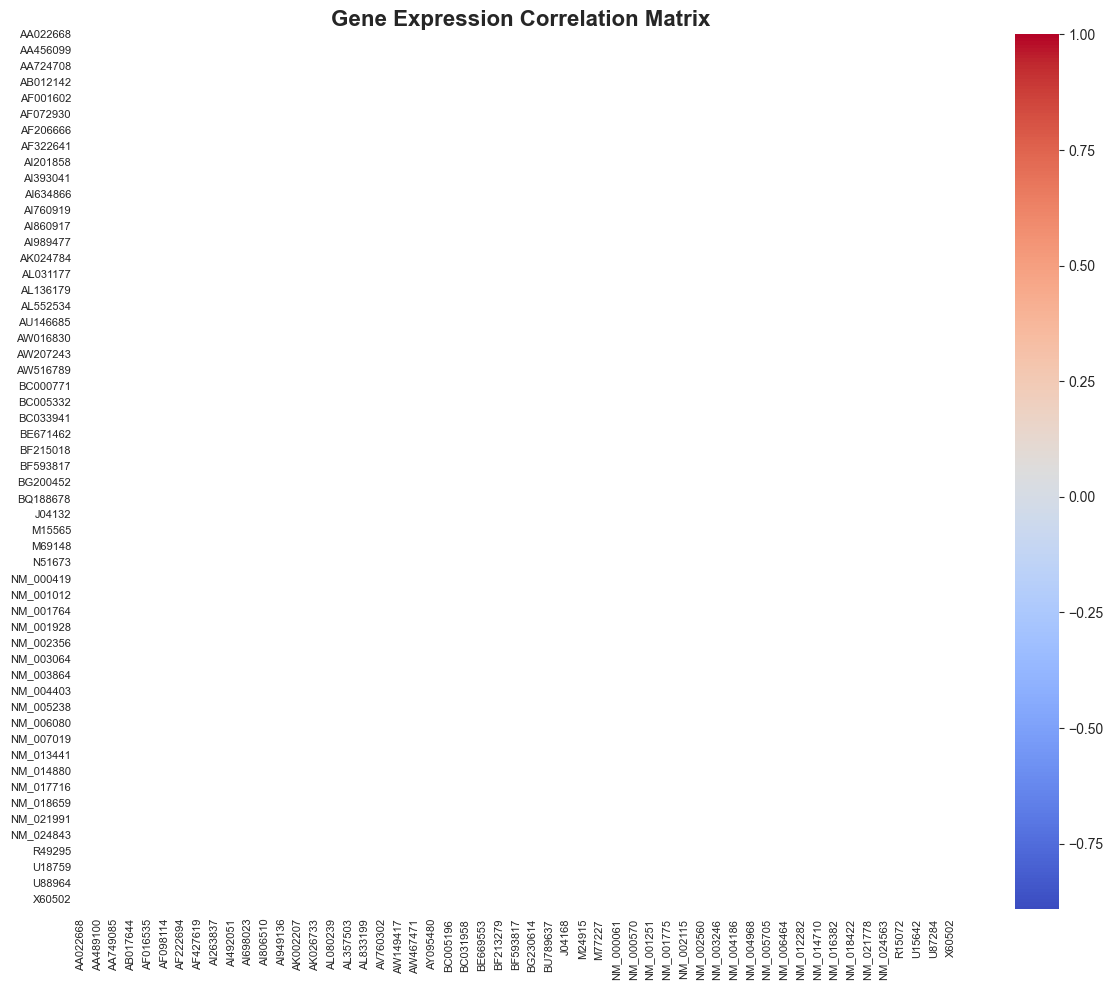

In [57]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Gene Expression Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### **Analysis Summary**

Display summary statistics and key findings from the exploratory data analysis.

In [30]:
print(f"Samples: {len(combined_df)}")
print(f"Genes: {len(gene_expression.columns)}")
print(f"Leukemia types: {len(leukemia_types.unique())}")
print(f"Significant genes (p < 0.05): {(anova_df['P-Value'] < 0.05).sum()}")
print(f"Total gene pairs: {len(corr_pairs_df)}")

Samples: 973
Genes: 1420
Leukemia types: 4
Significant genes (p < 0.05): 1378
Total gene pairs: 1007490


## **P4 - Model Development**

Building and comparing multiple machine learning models for leukemia classification, includes:
- Simple and multiple linear regression models
- Polynomial regression with pipelines
- Ridge and Lasso regularization models
- Neural Network models (using Keras/TensorFlow)
- Model evaluation with R-squared, MSE, and visualizations
- Prediction and decision making
- Model comparison and selection

### **Import Required Libraries**
Load essential libraries for model development, evaluation, and visualization.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### **Load and Prepare Data**

In [32]:
# load cleaned data
features_df = pd.read_csv('GSE13164_cleaned_features.csv', index_col=0)
labels_df = pd.read_csv('GSE13164_cleaned_labels.csv')

# combine features with labels
X = features_df.values
y = labels_df['Target_Code'].values
leukemia_types = labels_df['Leukemia_Type'].values
sample_ids = labels_df['Sample_ID'].values

# split data into training & testing sets (80-20 split)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

# standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")

Training set size: (778, 1420)
Testing set size: (195, 1420)


### **Model 1 - Simple Linear Regression (Baseline)**

In [33]:
model1_simple_lr = LinearRegression()
model1_simple_lr.fit(X_train_scaled[:, :1], y_train)

# predictions
y_train_pred_m1 = model1_simple_lr.predict(X_train_scaled[:, :1])
y_test_pred_m1 = model1_simple_lr.predict(X_test_scaled[:, :1])

# eval metrics
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

print(f"Training MSE: {train_mse_m1:.6f}")
print(f"Testing MSE:  {test_mse_m1:.6f}")
print(f"Training R²:  {train_r2_m1:.6f}")
print(f"Testing R²:   {test_r2_m1:.6f}")
print(f"Model Coefficients: {model1_simple_lr.coef_}")
print(f"Model Intercept: {model1_simple_lr.intercept_:.6f}")

Training MSE: 0.817679
Testing MSE:  0.833054
Training R²:  0.042449
Testing R²:   0.030280
Model Coefficients: [-0.19039117]
Model Intercept: 0.883033


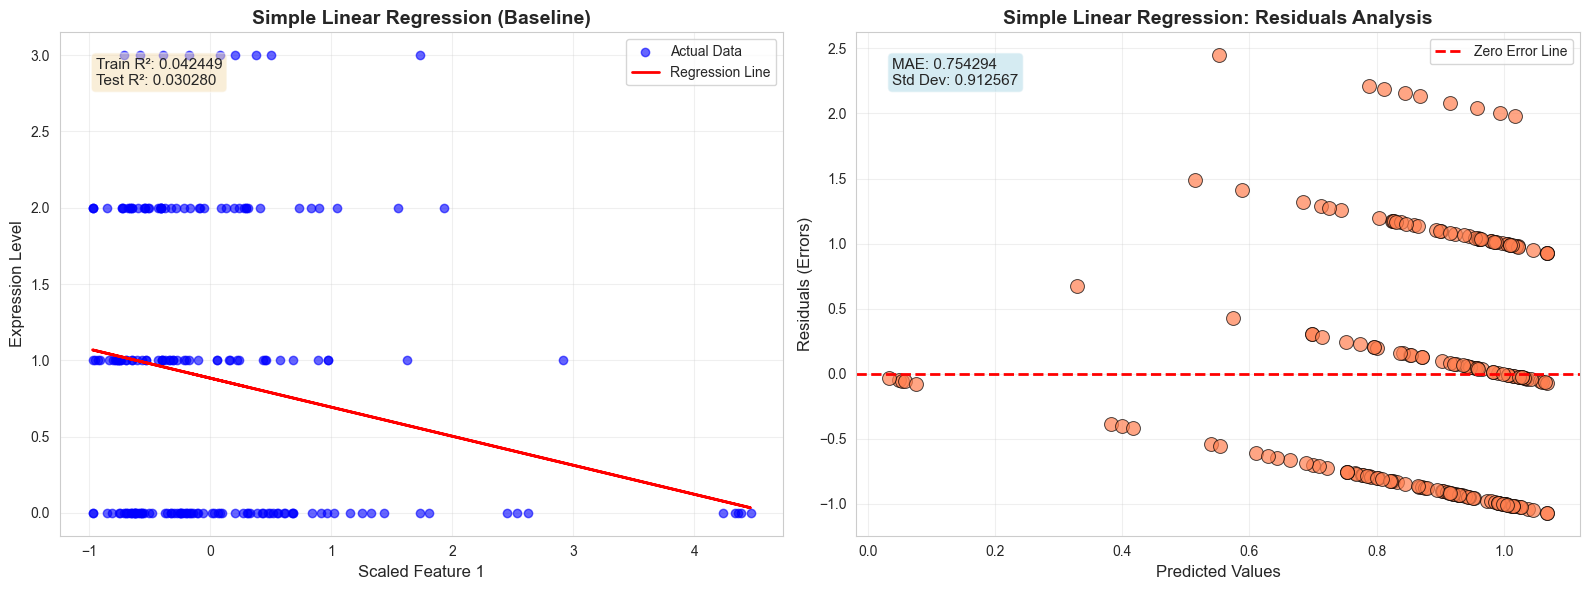

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Regression line with actual data
axes[0].scatter(X_test_scaled[:, :1], y_test, color='blue', label='Actual Data', alpha=0.6)
axes[0].plot(X_test_scaled[:, :1], y_test_pred_m1, color='red', label='Regression Line', linewidth=2)
axes[0].set_xlabel('Scaled Feature 1', fontsize=12)
axes[0].set_ylabel('Expression Level', fontsize=12)
axes[0].set_title('Simple Linear Regression (Baseline)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Add metrics text box
metrics_text = f'Train R²: {train_r2_m1:.6f}\nTest R²: {test_r2_m1:.6f}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right plot: Residuals analysis
residuals_m1 = y_test - y_test_pred_m1
axes[1].scatter(y_test_pred_m1, residuals_m1, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Errors)', fontsize=12)
axes[1].set_title('Simple Linear Regression: Residuals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Add residuals metrics text box
mae_m1 = np.mean(np.abs(residuals_m1))
residuals_text = f'MAE: {mae_m1:.6f}\nStd Dev: {np.std(residuals_m1):.6f}'
axes[1].text(0.05, 0.95, residuals_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **Model 2 - Multiple Linear Regression**

Build a linear regression model using all available gene expression features. This captures relationships across the entire feature space.

In [35]:
model2_multiple_lr = LinearRegression()
model2_multiple_lr.fit(X_train_scaled, y_train)

# predictions
y_train_pred_m2 = model2_multiple_lr.predict(X_train_scaled)
y_test_pred_m2 = model2_multiple_lr.predict(X_test_scaled)

train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

print(f"Training MSE: {train_mse_m2:.6f}")
print(f"Testing MSE:  {test_mse_m2:.6f}")
print(f"Training R²:  {train_r2_m2:.6f}")
print(f"Testing R²:   {test_r2_m2:.6f}")
print(f"Model Intercept: {model2_multiple_lr.intercept_:.6f}")
print(f"Number of coefficients: {len(model2_multiple_lr.coef_)}")

Training MSE: 0.000000
Testing MSE:  0.153705
Training R²:  1.000000
Testing R²:   0.821079
Model Intercept: 0.883033
Number of coefficients: 1420


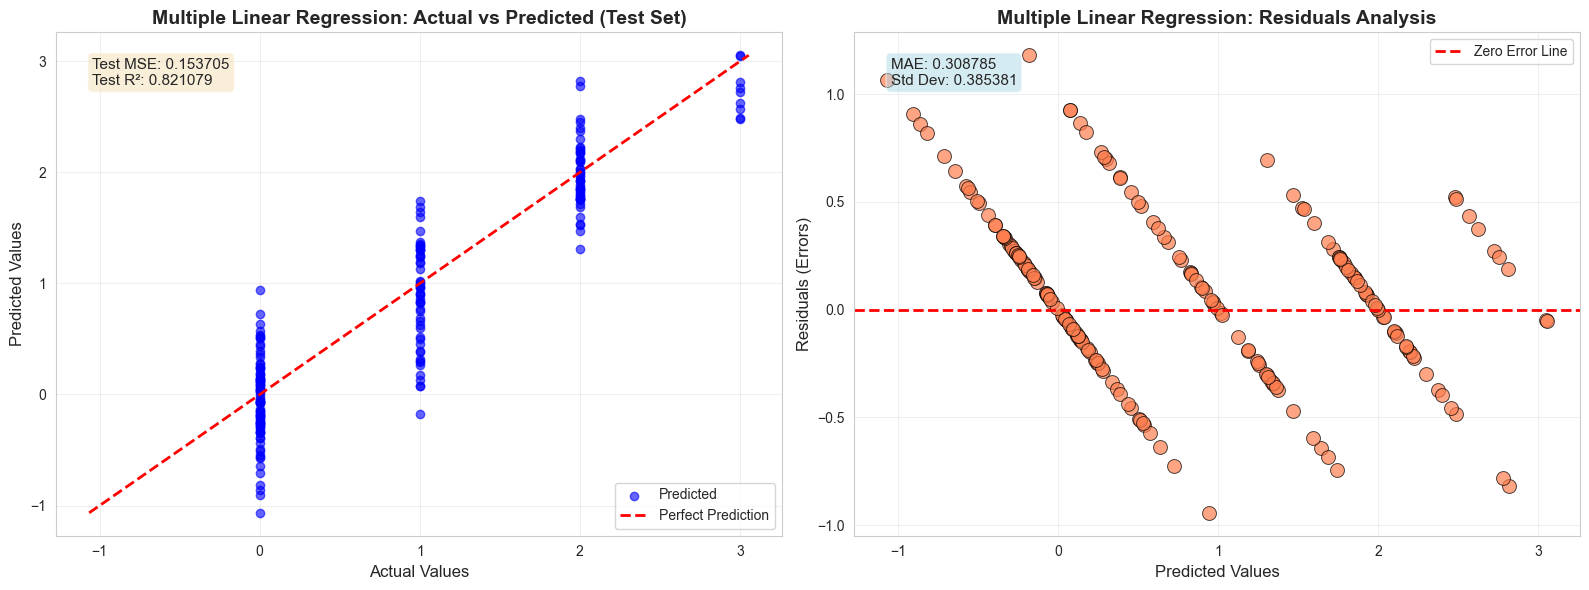

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# multiple lr
axes[0].scatter(y_test, y_test_pred_m2, alpha=0.6, color='blue', label='Predicted')
min_val = min(y_test.min(), y_test_pred_m2.min())
max_val = max(y_test.max(), y_test_pred_m2.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Multiple Linear Regression: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
metrics_text = f'Test MSE: {test_mse_m2:.6f}\nTest R²: {test_r2_m2:.6f}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# residual analysis
residuals_m2 = y_test - y_test_pred_m2
axes[1].scatter(y_test_pred_m2, residuals_m2, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Errors)', fontsize=12)
axes[1].set_title('Multiple Linear Regression: Residuals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
mae_m2 = np.mean(np.abs(residuals_m2))
residuals_text = f'MAE: {mae_m2:.6f}\nStd Dev: {np.std(residuals_m2):.6f}'
axes[1].text(0.05, 0.95, residuals_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **Model 3 - Polynomial Regression with Pipeline**
Used scikit-learn pipelines to capture non-linear relationships between genes and leukemia types.

In [37]:
poly_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear_regression', LinearRegression())
])

model3_poly = poly_pipeline.fit(X_train_scaled, y_train)

# predictions
y_train_pred_m3 = model3_poly.predict(X_train_scaled)
y_test_pred_m3 = model3_poly.predict(X_test_scaled)

# eval metrics
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

print(f"Training MSE: {train_mse_m3:.6f}")
print(f"Testing MSE:  {test_mse_m3:.6f}")
print(f"Training R²:  {train_r2_m3:.6f}")
print(f"Testing R²:   {test_r2_m3:.6f}")
print(f"Polynomial features shape: {model3_poly.named_steps['poly_features'].n_output_features_}")

Training MSE: 0.000000
Testing MSE:  0.032354
Training R²:  1.000000
Testing R²:   0.962338
Polynomial features shape: 1010330


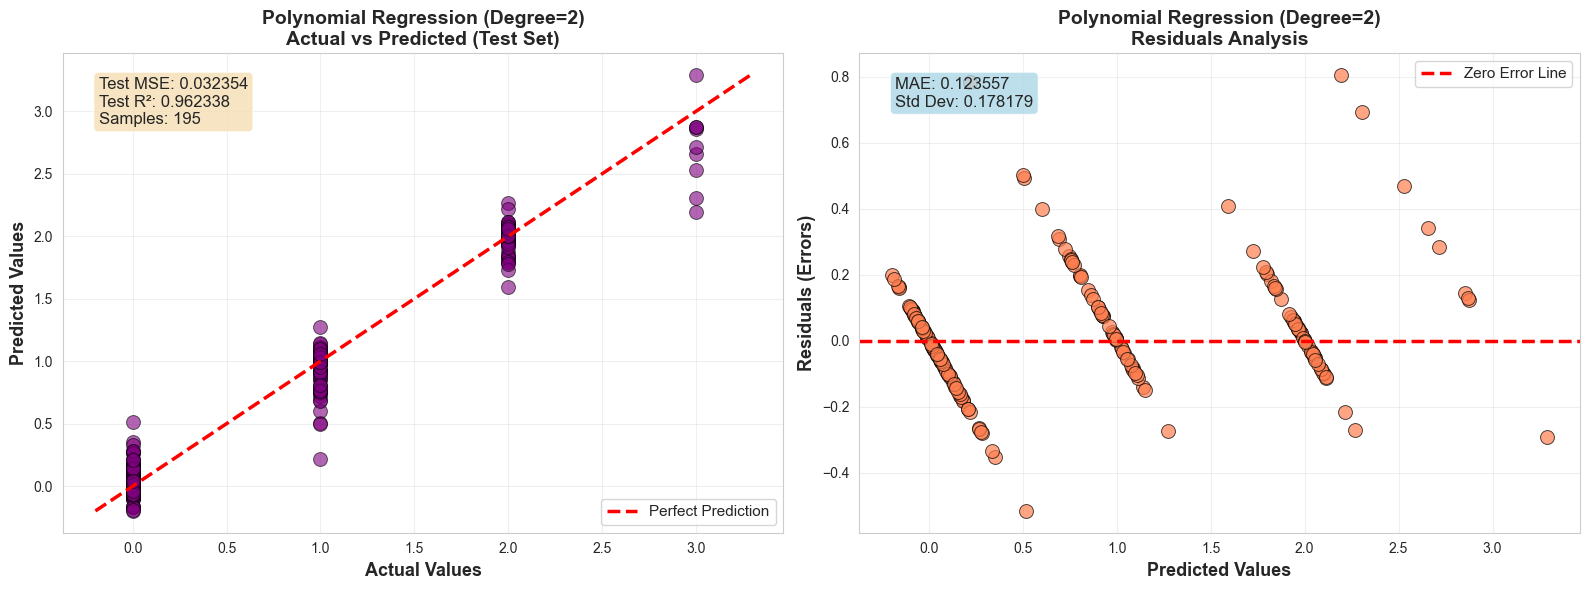

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# polynomial lr
axes[0].scatter(y_test, y_test_pred_m3, alpha=0.6, s=100, color='purple', edgecolors='k', linewidth=0.7)
min_val = min(y_test.min(), y_test_pred_m3.min())
max_val = max(y_test.max(), y_test_pred_m3.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Predicted Values', fontsize=13, fontweight='bold')
axes[0].set_title('Polynomial Regression (Degree=2)\nActual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
metrics_text = f'Test MSE: {test_mse_m3:.6f}\nTest R²: {test_r2_m3:.6f}\nSamples: {len(y_test)}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# residuals analysis
residuals_m3 = y_test - y_test_pred_m3
axes[1].scatter(y_test_pred_m3, residuals_m3, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2.5, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Residuals (Errors)', fontsize=13, fontweight='bold')
axes[1].set_title('Polynomial Regression (Degree=2)\nResiduals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
mae_m3 = np.mean(np.abs(residuals_m3))
axes[1].text(0.05, 0.95, f'MAE: {mae_m3:.6f}\nStd Dev: {np.std(residuals_m3):.6f}', 
            transform=axes[1].transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

### **Model 4 - Ridge Regression (L2 Regularization)**
To reduce overfitting and improve generalization on test data.

In [39]:
# ridge regression with hyperparameter tuning
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

model4_ridge = ridge_grid.best_estimator_

# predictions
y_train_pred_m4 = model4_ridge.predict(X_train_scaled)
y_test_pred_m4 = model4_ridge.predict(X_test_scaled)

# eval metrics
train_mse_m4 = mean_squared_error(y_train, y_train_pred_m4)
test_mse_m4 = mean_squared_error(y_test, y_test_pred_m4)
train_r2_m4 = r2_score(y_train, y_train_pred_m4)
test_r2_m4 = r2_score(y_test, y_test_pred_m4)

print(f"Best alpha (regularization): {ridge_grid.best_params_['alpha']}")
print(f"Training MSE: {train_mse_m4:.6f}")
print(f"Testing MSE:  {test_mse_m4:.6f}")
print(f"Training R²:  {train_r2_m4:.6f}")
print(f"Testing R²:   {test_r2_m4:.6f}")

Best alpha (regularization): 100
Training MSE: 0.008942
Testing MSE:  0.067925
Training R²:  0.989528
Testing R²:   0.920932


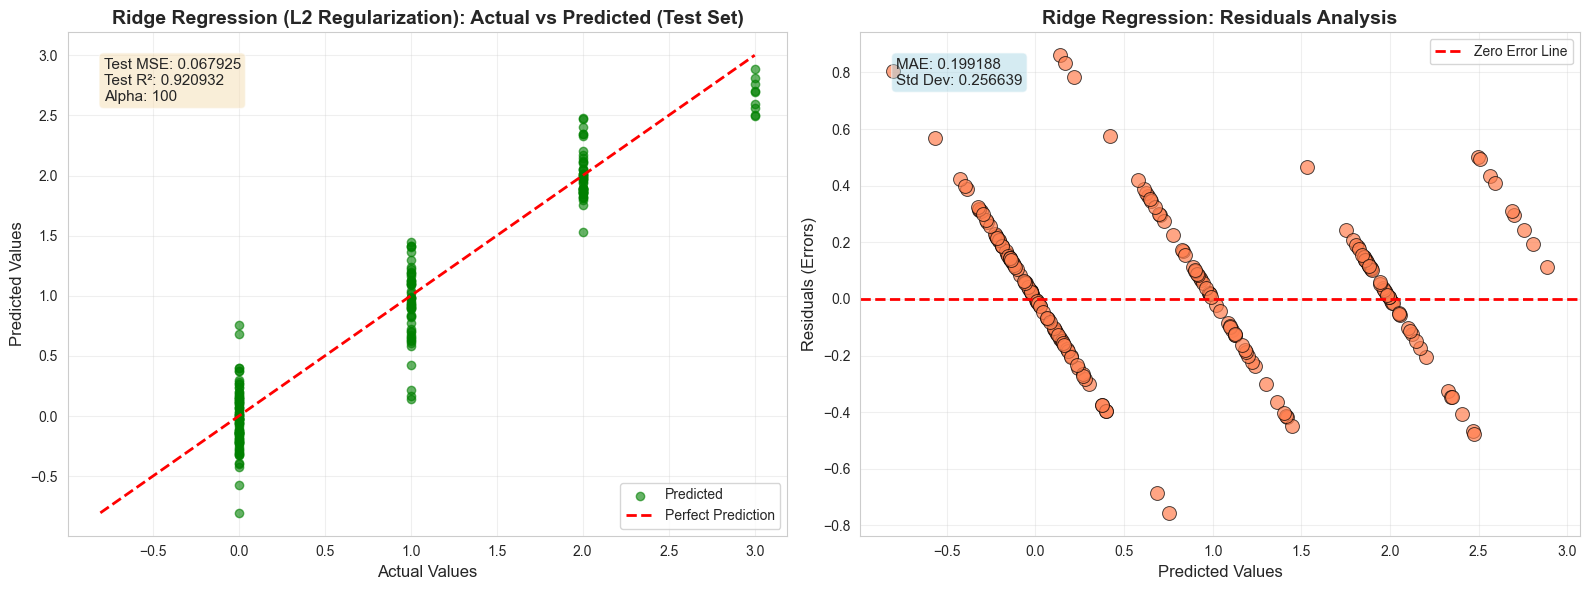

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Actual vs Predicted
axes[0].scatter(y_test, y_test_pred_m4, alpha=0.6, color='green', label='Predicted')

# Add diagonal reference line (perfect prediction)
min_val = min(y_test.min(), y_test_pred_m4.min())
max_val = max(y_test.max(), y_test_pred_m4.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Labels and title for left plot
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Ridge Regression (L2 Regularization): Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Add metrics text box
metrics_text = f'Test MSE: {test_mse_m4:.6f}\nTest R²: {test_r2_m4:.6f}\nAlpha: {ridge_grid.best_params_["alpha"]}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right plot: Residuals Analysis
residuals_m4 = y_test - y_test_pred_m4
axes[1].scatter(y_test_pred_m4, residuals_m4, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Errors)', fontsize=12)
axes[1].set_title('Ridge Regression: Residuals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Add residuals metrics text box
mae_m4 = np.mean(np.abs(residuals_m4))
residuals_text = f'MAE: {mae_m4:.6f}\nStd Dev: {np.std(residuals_m4):.6f}'
axes[1].text(0.05, 0.95, residuals_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **Model 5 - Lasso Regression (L1 Regularization)**
To feature selection and improved interpretability.

In [41]:
# lasso reg with hyperparameter tuning
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

model5_lasso = lasso_grid.best_estimator_

# predictions
y_train_pred_m5 = model5_lasso.predict(X_train_scaled)
y_test_pred_m5 = model5_lasso.predict(X_test_scaled)

# eval metrics
train_mse_m5 = mean_squared_error(y_train, y_train_pred_m5)
test_mse_m5 = mean_squared_error(y_test, y_test_pred_m5)
train_r2_m5 = r2_score(y_train, y_train_pred_m5)
test_r2_m5 = r2_score(y_test, y_test_pred_m5)

# count non-zero coefficients (selected features)
non_zero_coefs = np.sum(model5_lasso.coef_ != 0)

print(f"Best alpha (regularization): {lasso_grid.best_params_['alpha']}")
print(f"Training MSE: {train_mse_m5:.6f}")
print(f"Testing MSE:  {test_mse_m5:.6f}")
print(f"Training R²:  {train_r2_m5:.6f}")
print(f"Testing R²:   {test_r2_m5:.6f}")
print(f"Selected features: {non_zero_coefs} out of {len(model5_lasso.coef_)}")

Best alpha (regularization): 0.01
Training MSE: 0.044228
Testing MSE:  0.059842
Training R²:  0.948206
Testing R²:   0.930341
Selected features: 203 out of 1420


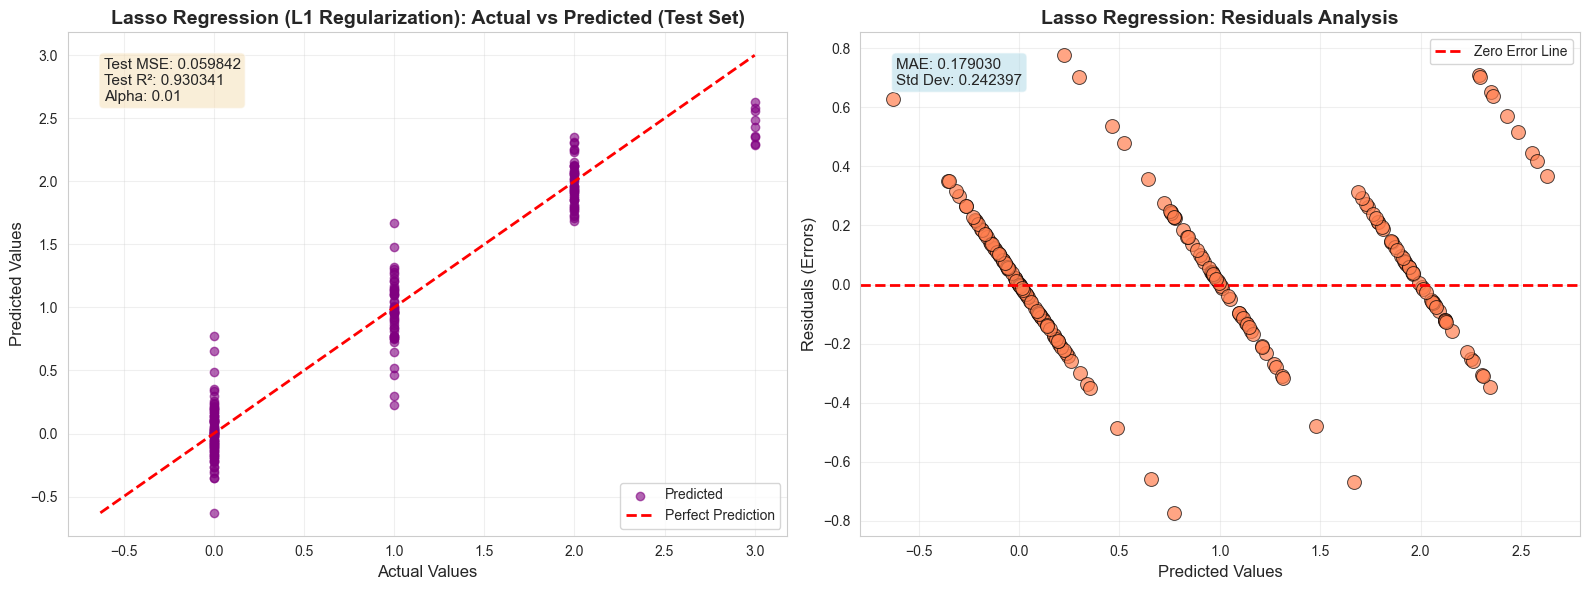

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# lasso reg
axes[0].scatter(y_test, y_test_pred_m5, alpha=0.6, color='purple', label='Predicted')
min_val = min(y_test.min(), y_test_pred_m5.min())
max_val = max(y_test.max(), y_test_pred_m5.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Lasso Regression (L1 Regularization): Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
metrics_text = f'Test MSE: {test_mse_m5:.6f}\nTest R²: {test_r2_m5:.6f}\nAlpha: {lasso_grid.best_params_["alpha"]}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# residual analysis
residuals_m5 = y_test - y_test_pred_m5
axes[1].scatter(y_test_pred_m5, residuals_m5, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Errors)', fontsize=12)
axes[1].set_title('Lasso Regression: Residuals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
mae_m5 = np.mean(np.abs(residuals_m5))
residuals_text = f'MAE: {mae_m5:.6f}\nStd Dev: {np.std(residuals_m5):.6f}'
axes[1].text(0.05, 0.95, residuals_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **Model 6 - Neural Network**
Build a deep neural network model using Keras/TensorFlow with multiple layers, batch normalization, and dropout for improved performance and generalization.

In [43]:
model6_nn = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='linear')  # Linear activation for regression
])

# compile the model
model6_nn.compile(optimizer=Adam(learning_rate=0.001), 
                   loss='mse', 
                   metrics=['mae'])

# train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model6_nn.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# predictions
y_train_pred_m6 = model6_nn.predict(X_train_scaled, verbose=0).flatten()
y_test_pred_m6 = model6_nn.predict(X_test_scaled, verbose=0).flatten()

# eval metrics
train_mse_m6 = mean_squared_error(y_train, y_train_pred_m6)
test_mse_m6 = mean_squared_error(y_test, y_test_pred_m6)
train_r2_m6 = r2_score(y_train, y_train_pred_m6)
test_r2_m6 = r2_score(y_test, y_test_pred_m6)

print(f"Training MSE: {train_mse_m6:.6f}")
print(f"Testing MSE:  {test_mse_m6:.6f}")
print(f"Training R²:  {train_r2_m6:.6f}")
print(f"Testing R²:   {test_r2_m6:.6f}")
print(f"Training epochs: {len(history.history['loss'])}")
print("Model Summary:")
print(model6_nn.summary())

Training MSE: 0.016453
Testing MSE:  0.019034
Training R²:  0.980732
Testing R²:   0.977844
Training epochs: 65
Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       363,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,709 (4.67 MB)

 Trainable params: 407,937 (1.56 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 815,876 (3.11 MB)

None


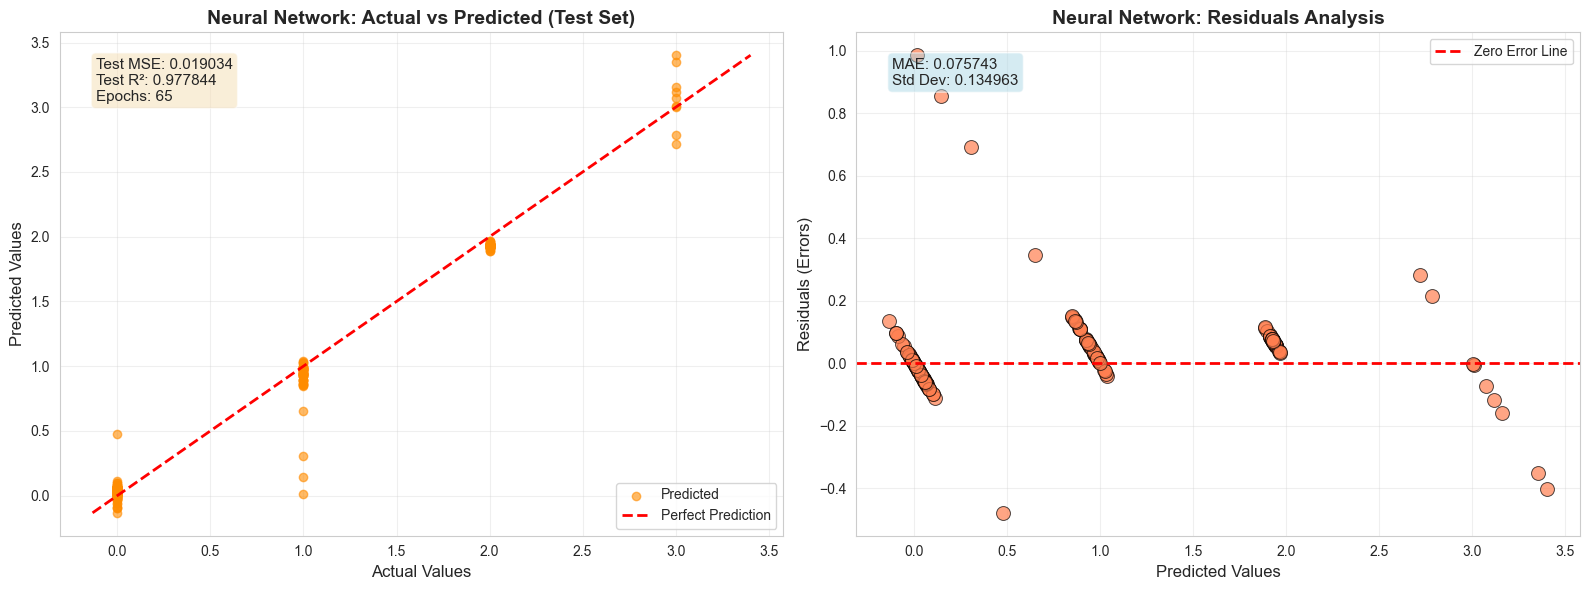

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# neural network
axes[0].scatter(y_test, y_test_pred_m6, alpha=0.6, color='darkorange', label='Predicted')
min_val = min(y_test.min(), y_test_pred_m6.min())
max_val = max(y_test.max(), y_test_pred_m6.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Neural Network: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
metrics_text = f'Test MSE: {test_mse_m6:.6f}\nTest R²: {test_r2_m6:.6f}\nEpochs: {len(history.history["loss"])}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# residuals analysis
residuals_m6 = y_test - y_test_pred_m6
axes[1].scatter(y_test_pred_m6, residuals_m6, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Errors)', fontsize=12)
axes[1].set_title('Neural Network: Residuals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
mae_m6 = np.mean(np.abs(residuals_m6))
residuals_text = f'MAE: {mae_m6:.6f}\nStd Dev: {np.std(residuals_m6):.6f}'
axes[1].text(0.05, 0.95, residuals_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **Model 7 - Random Forest Regressor**

In [45]:
from sklearn.ensemble import RandomForestRegressor

# random forest reg with hyperparameter tuning
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, 30], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

model7_rf = rf_grid.best_estimator_

# predictions
y_train_pred_m7 = model7_rf.predict(X_train_scaled)
y_test_pred_m7 = model7_rf.predict(X_test_scaled)

# eval metrics
train_mse_m7 = mean_squared_error(y_train, y_train_pred_m7)
test_mse_m7 = mean_squared_error(y_test, y_test_pred_m7)
train_r2_m7 = r2_score(y_train, y_train_pred_m7)
test_r2_m7 = r2_score(y_test, y_test_pred_m7)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Training MSE: {train_mse_m7:.6f}")
print(f"Testing MSE:  {test_mse_m7:.6f}")
print(f"Training R²:  {train_r2_m7:.6f}")
print(f"Testing R²:   {test_r2_m7:.6f}")
print(f"Feature importance (top 10):")
feature_importance = sorted(enumerate(model7_rf.feature_importances_), key=lambda x: x[1], reverse=True)
for idx, importance in feature_importance[:10]:
    print(f"  Feature {idx}: {importance:.6f}")

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Training MSE: 0.009576
Testing MSE:  0.061498
Training R²:  0.988786
Testing R²:   0.928413
Feature importance (top 10):
  Feature 803: 0.594421
  Feature 281: 0.081622
  Feature 338: 0.060883
  Feature 212: 0.032133
  Feature 601: 0.029718
  Feature 760: 0.014735
  Feature 416: 0.014681
  Feature 69: 0.011723
  Feature 1135: 0.010500
  Feature 39: 0.006736


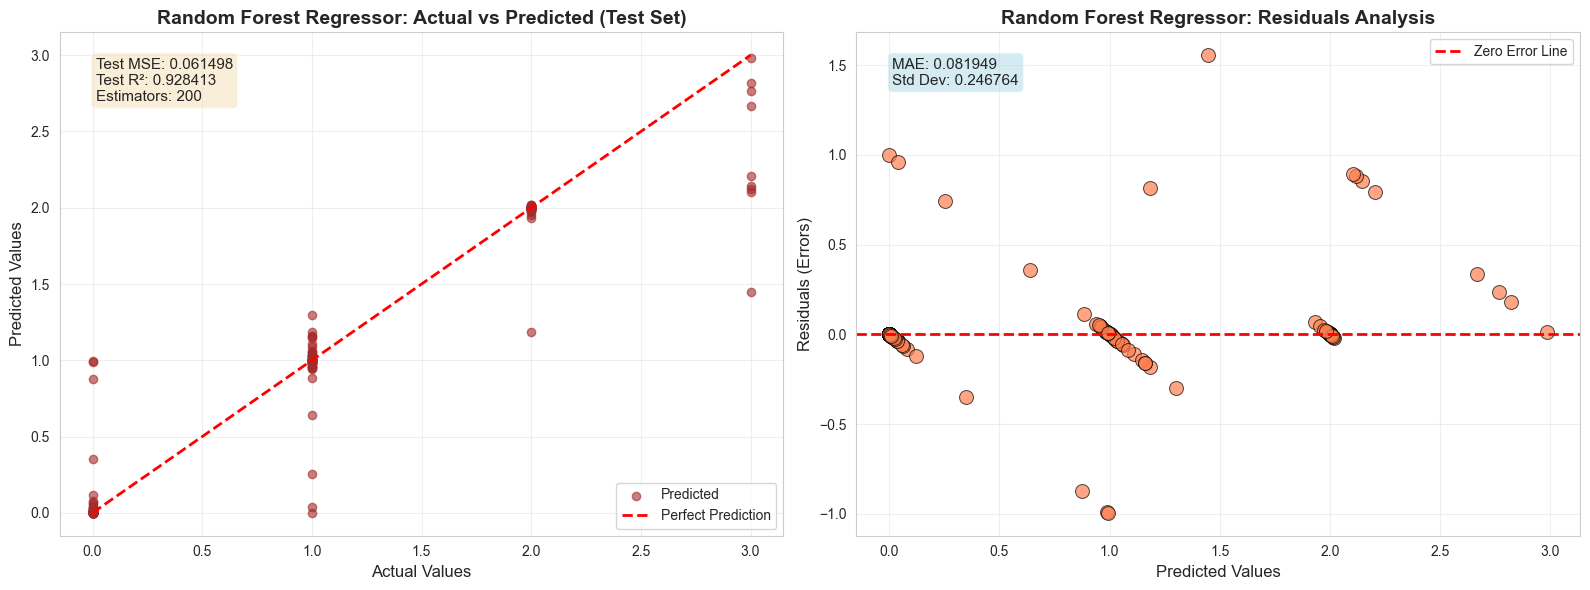

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# random forest
axes[0].scatter(y_test, y_test_pred_m7, alpha=0.6, color='brown', label='Predicted')

# Add diagonal reference line (perfect prediction)
min_val = min(y_test.min(), y_test_pred_m7.min())
max_val = max(y_test.max(), y_test_pred_m7.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Random Forest Regressor: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
metrics_text = f'Test MSE: {test_mse_m7:.6f}\nTest R²: {test_r2_m7:.6f}\nEstimators: {rf_grid.best_params_["n_estimators"]}'
axes[0].text(0.05, 0.95, metrics_text, transform=axes[0].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# residuals analysis
residuals_m7 = y_test - y_test_pred_m7
axes[1].scatter(y_test_pred_m7, residuals_m7, alpha=0.7, s=100, color='coral', edgecolors='k', linewidth=0.7)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals (Errors)', fontsize=12)
axes[1].set_title('Random Forest Regressor: Residuals Analysis', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
mae_m7 = np.mean(np.abs(residuals_m7))
residuals_text = f'MAE: {mae_m7:.6f}\nStd Dev: {np.std(residuals_m7):.6f}'
axes[1].text(0.05, 0.95, residuals_text, transform=axes[1].transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

### **R-squared and MSE Comparison Among Models**

In [47]:
# comparison df
comparison_df = pd.DataFrame({
    'Model': [
        'Simple LR',
        'Multiple LR',
        'Polynomial (deg=2)',
        'Ridge',
        'Lasso',
        'Neural Network',
        'Random Forest'
    ],
    'Train MSE': [train_mse_m1, train_mse_m2, train_mse_m3, train_mse_m4, train_mse_m5, train_mse_m6, train_mse_m7],
    'Test MSE': [test_mse_m1, test_mse_m2, test_mse_m3, test_mse_m4, test_mse_m5, test_mse_m6, test_mse_m7],
    'Train R²': [train_r2_m1, train_r2_m2, train_r2_m3, train_r2_m4, train_r2_m5, train_r2_m6, train_r2_m7],
    'Test R²': [test_r2_m1, test_r2_m2, test_r2_m3, test_r2_m4, test_r2_m5, test_r2_m6, test_r2_m7]
})
print(comparison_df.to_string(index=False))

# best model (lowest mse & highest r2)
best_test_r2_idx = comparison_df['Test R²'].idxmax()
best_test_mse_idx = comparison_df['Test MSE'].idxmin()
print(f"\nBest Test R²: {comparison_df.loc[best_test_r2_idx, 'Model']} ({comparison_df.loc[best_test_r2_idx, 'Test R²']:.6f})")
print(f"Best Test MSE: {comparison_df.loc[best_test_mse_idx, 'Model']} ({comparison_df.loc[best_test_mse_idx, 'Test MSE']:.6f})")

             Model    Train MSE  Test MSE  Train R²  Test R²
         Simple LR 8.176793e-01  0.833054  0.042449 0.030280
       Multiple LR 1.730419e-29  0.153705  1.000000 0.821079
Polynomial (deg=2) 4.880883e-28  0.032354  1.000000 0.962338
             Ridge 8.942474e-03  0.067925  0.989528 0.920932
             Lasso 4.422814e-02  0.059842  0.948206 0.930341
    Neural Network 1.645333e-02  0.019034  0.980732 0.977844
     Random Forest 9.576060e-03  0.061498  0.988786 0.928413

Best Test R²: Neural Network (0.977844)
Best Test MSE: Neural Network (0.019034)


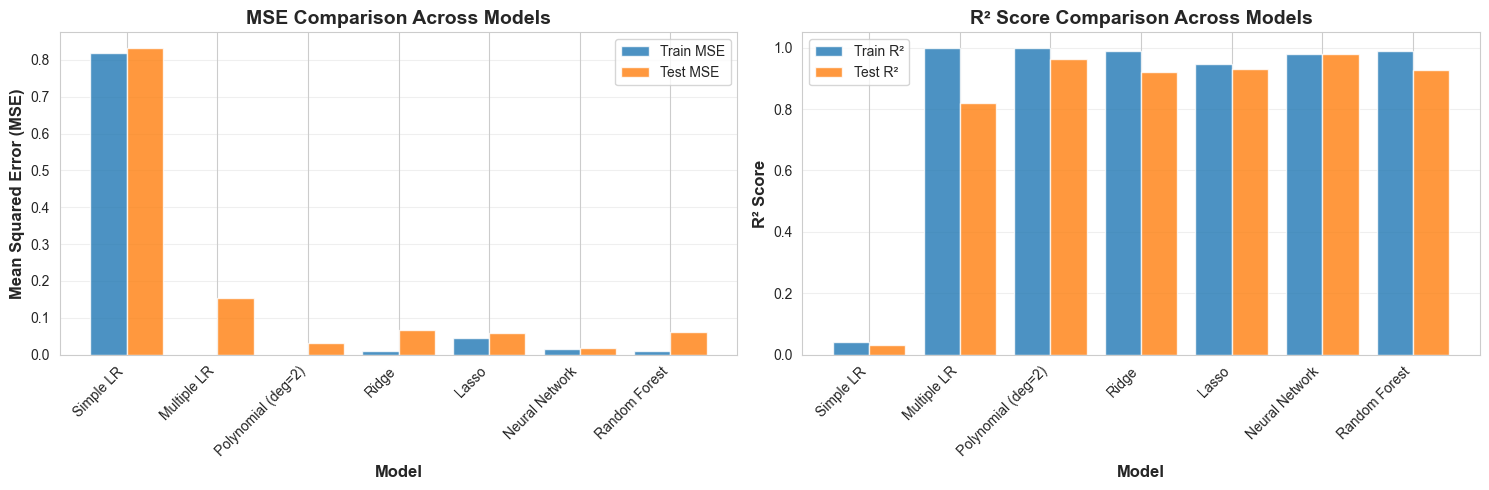

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# mse comparison
x_pos = np.arange(len(comparison_df))
axes[0].bar(x_pos - 0.2, comparison_df['Train MSE'], 0.4, label='Train MSE', alpha=0.8)
axes[0].bar(x_pos + 0.2, comparison_df['Test MSE'], 0.4, label='Test MSE', alpha=0.8)
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('MSE Comparison Across Models', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# r2 comparison
axes[1].bar(x_pos - 0.2, comparison_df['Train R²'], 0.4, label='Train R²', alpha=0.8)
axes[1].bar(x_pos + 0.2, comparison_df['Test R²'], 0.4, label='Test R²', alpha=0.8)
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('R² Score Comparison Across Models', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### **Prediction and Decision Making**

Make predictions on test data using the best model and demonstrate classification of samples by leukemia type based on continuous predictions.


In [49]:
# neural network for predictions
best_model = model6_nn
y_test_pred_best = y_test_pred_m6
y_test_pred_class = np.round(y_test_pred_best).astype(int)
y_test_pred_class = np.clip(y_test_pred_class, 0, 3)  # Ensure within valid range
class_to_type = {0: 'ALL', 1: 'AML', 2: 'CLL', 3: 'CML'}
y_test_true_types = [class_to_type[y] for y in y_test]
y_test_pred_types = [class_to_type[y] for y in y_test_pred_class]

# predictions df
predictions_df = pd.DataFrame({
    'Sample_ID': sample_ids[idx_test],
    'Actual_Class': y_test,
    'Predicted_Class': y_test_pred_class,
    'Continuous_Prediction': y_test_pred_best,
    'Actual_Type': y_test_true_types,
    'Predicted_Type': y_test_pred_types,
    'Prediction_Error': y_test - y_test_pred_best,
    'Correct': y_test == y_test_pred_class
})

print("Predictions & Decision Making (Test Set - First 15 samples):")
print(predictions_df.head(15).to_string(index=False))

# classification accuracy
accuracy = np.sum(predictions_df['Correct']) / len(predictions_df)
print(f"\nOverall Classification Accuracy: {accuracy:.4f} ({np.sum(predictions_df['Correct'])}/{len(predictions_df)})")

# accuracy by leukemia type
print("\nAccuracy by Leukemia Type:")
for ltype in ['ALL', 'AML', 'CLL', 'CML']:
    mask = predictions_df['Actual_Type'] == ltype
    type_acc = np.sum(predictions_df.loc[mask, 'Correct']) / np.sum(mask) if np.sum(mask) > 0 else 0
    print(f"  {ltype}: {type_acc:.4f} ({np.sum(predictions_df.loc[mask, 'Correct'])}/{np.sum(mask)})")

# misclassified samples
print("\nMisclasified Samples:")
misclassified = predictions_df[~predictions_df['Correct']]
print(misclassified[['Sample_ID', 'Actual_Type', 'Predicted_Type', 'Continuous_Prediction', 'Prediction_Error']].to_string(index=False))

Predictions & Decision Making (Test Set - First 15 samples):
Sample_ID  Actual_Class  Predicted_Class  Continuous_Prediction Actual_Type Predicted_Type  Prediction_Error  Correct
GSM332231             0                0               0.044764         ALL            ALL         -0.044764     True
GSM332565             1                1               0.888988         AML            AML          0.111012     True
GSM332829             0                0              -0.027996         ALL            ALL          0.027996     True
GSM332555             0                0               0.045162         ALL            ALL         -0.045162     True
GSM331842             0                0              -0.006682         ALL            ALL          0.006682     True
GSM332163             1                1               0.941252         AML            AML          0.058748     True
GSM332650             1                1               0.943839         AML            AML          0.056161     

## **P5 - Model Evaluation**

### **Neural Network: Training History**

Plot the training history showing loss curves to analyze model convergence during training.


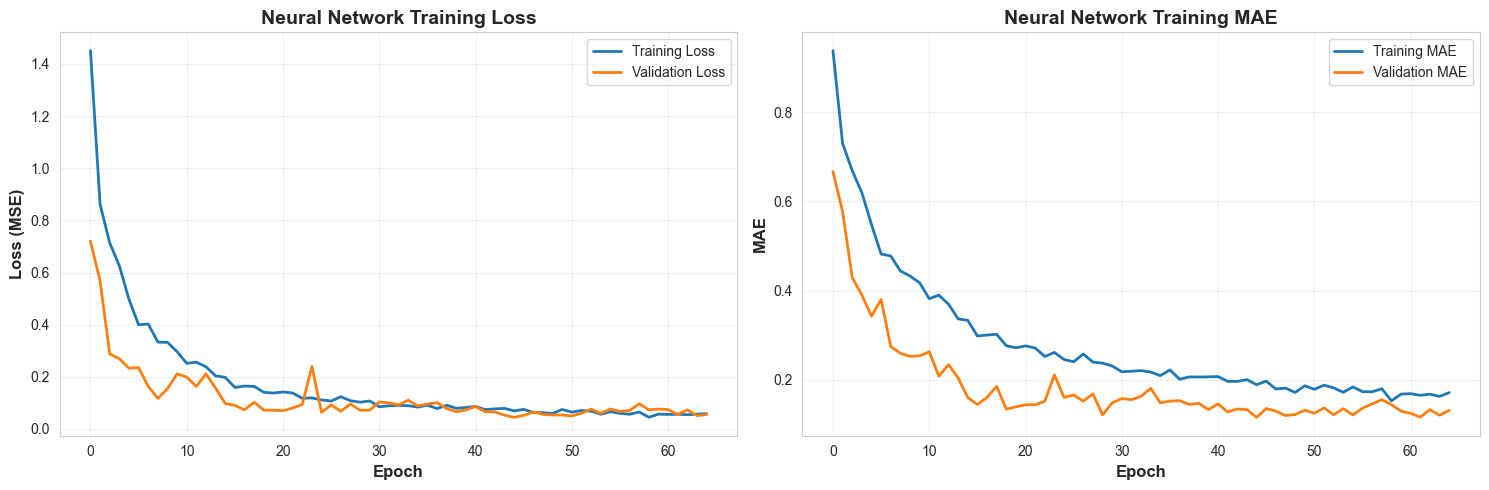

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Neural Network Training Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curves
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE', fontsize=12, fontweight='bold')
axes[1].set_title('Neural Network Training MAE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **Neural Network: Confusion Matrix and Classification Report**

Display confusion matrix and detailed classification metrics for the best model.


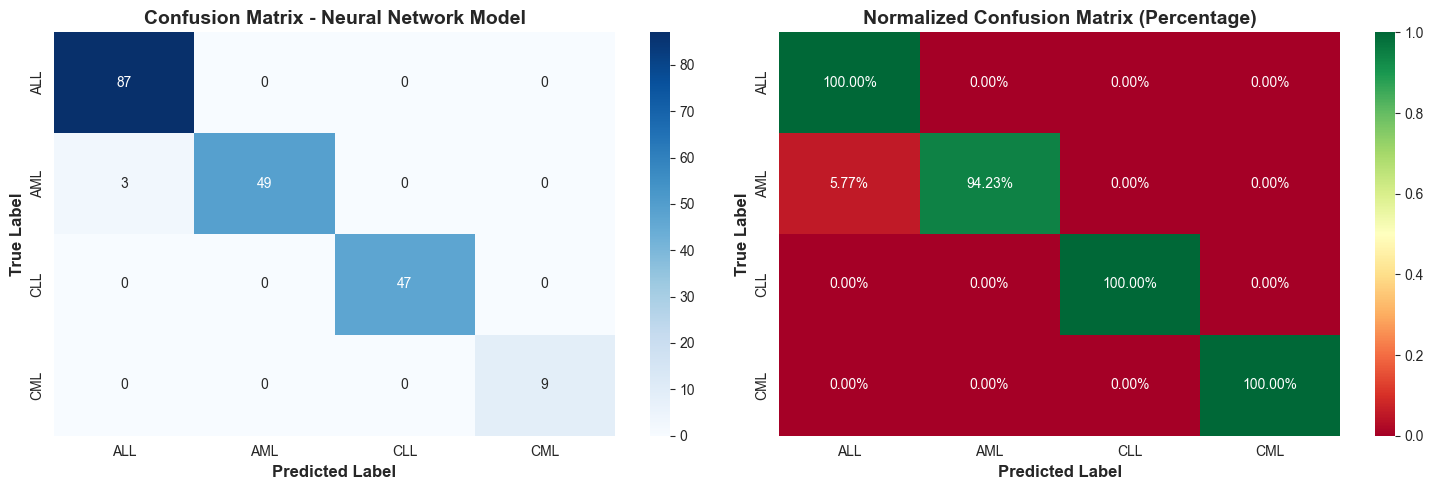

In [51]:
cm = confusion_matrix(y_test, y_test_pred_class)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['ALL', 'AML', 'CLL', 'CML'],
            yticklabels=['ALL', 'AML', 'CLL', 'CML'])
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix - Neural Network Model', fontsize=14, fontweight='bold')

# normalized confusion matrix (%)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', cbar=True, ax=axes[1],
            xticklabels=['ALL', 'AML', 'CLL', 'CML'],
            yticklabels=['ALL', 'AML', 'CLL', 'CML'])
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [52]:

# Classification report
print("Detailed Classification Report:")
class_names = ['ALL', 'AML', 'CLL', 'CML']
print(classification_report(y_test, y_test_pred_class, target_names=class_names, digits=4))

Detailed Classification Report:
              precision    recall  f1-score   support

         ALL     0.9667    1.0000    0.9831        87
         AML     1.0000    0.9423    0.9703        52
         CLL     1.0000    1.0000    1.0000        47
         CML     1.0000    1.0000    1.0000         9

    accuracy                         0.9846       195
   macro avg     0.9917    0.9856    0.9883       195
weighted avg     0.9851    0.9846    0.9845       195



### **Over-fiting, Under-fitting & Model Selection**

In [53]:
# Display the comparison DataFrame again for context
print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Analyze differences between train and test metrics
comparison_df['R2_Diff (Train - Test)'] = comparison_df['Train R²'] - comparison_df['Test R²']
comparison_df['MSE_Diff (Test - Train)'] = comparison_df['Test MSE'] - comparison_df['Train MSE']

print("\nPerformance Differences (Train vs. Test):")
print(comparison_df[['Model', 'R2_Diff (Train - Test)', 'MSE_Diff (Test - Train)']].to_string(index=False))

print("\nInterpretation of Differences:")
print("- Large positive R²_Diff or MSE_Diff indicates potential overfitting (model performs much better on training data).")
print("- Both Train & Test metrics being low (e.g., R² close to 0 or negative, high MSE) indicates underfitting.")
print("- Small differences and high R² low MSE on both sets indicate a good fit.")

Model Performance Comparison:
             Model    Train MSE  Test MSE  Train R²  Test R²
         Simple LR 8.176793e-01  0.833054  0.042449 0.030280
       Multiple LR 1.730419e-29  0.153705  1.000000 0.821079
Polynomial (deg=2) 4.880883e-28  0.032354  1.000000 0.962338
             Ridge 8.942474e-03  0.067925  0.989528 0.920932
             Lasso 4.422814e-02  0.059842  0.948206 0.930341
    Neural Network 1.645333e-02  0.019034  0.980732 0.977844
     Random Forest 9.576060e-03  0.061498  0.988786 0.928413

Performance Differences (Train vs. Test):
             Model  R2_Diff (Train - Test)  MSE_Diff (Test - Train)
         Simple LR                0.012170                 0.015375
       Multiple LR                0.178921                 0.153705
Polynomial (deg=2)                0.037662                 0.032354
             Ridge                0.068596                 0.058982
             Lasso                0.017865                 0.015613
    Neural Network             

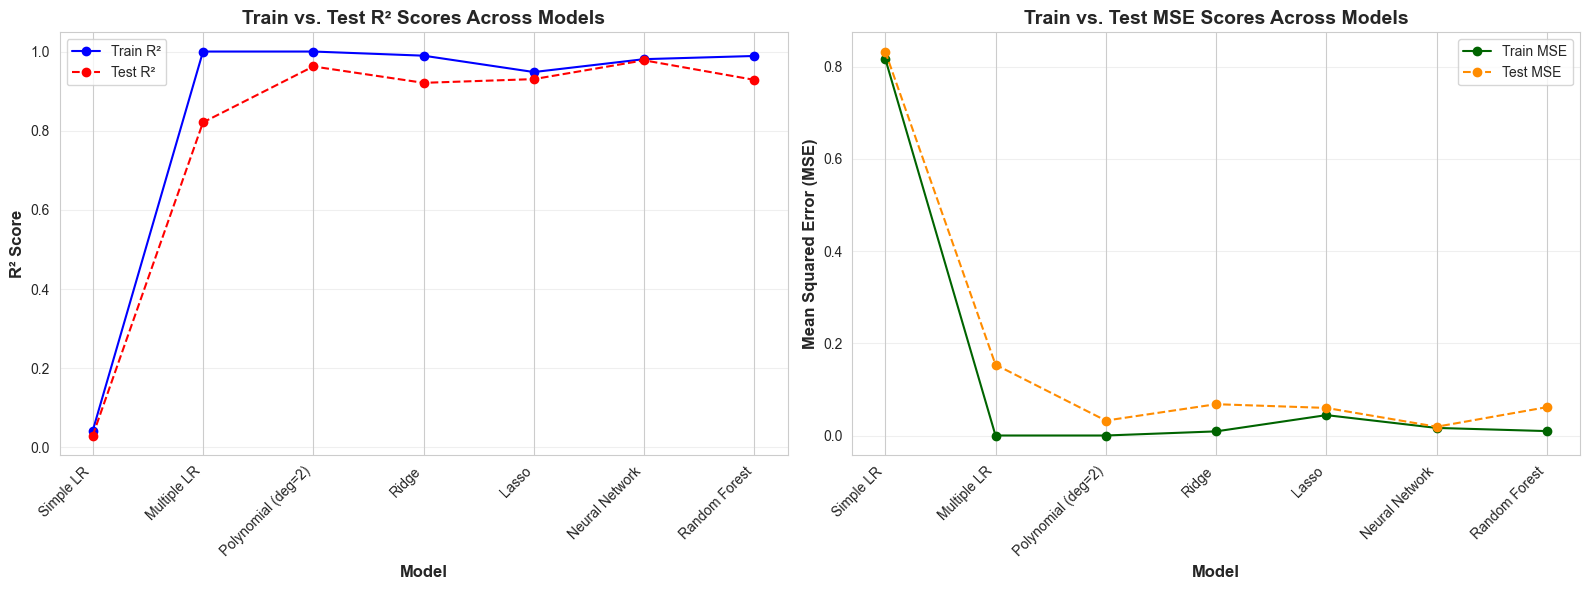

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# r2 Scores
axes[0].plot(comparison_df['Model'], comparison_df['Train R²'], marker='o', linestyle='-', label='Train R²', color='blue')
axes[0].plot(comparison_df['Model'], comparison_df['Test R²'], marker='o', linestyle='--', label='Test R²', color='red')
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Train vs. Test R² Scores Across Models', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(comparison_df['Model'])))
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# mse Scores
axes[1].plot(comparison_df['Model'], comparison_df['Train MSE'], marker='o', linestyle='-', label='Train MSE', color='darkgreen')
axes[1].plot(comparison_df['Model'], comparison_df['Test MSE'], marker='o', linestyle='--', label='Test MSE', color='darkorange')
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[1].set_title('Train vs. Test MSE Scores Across Models', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(comparison_df['Model'])))
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Random

### **16. Model Development Flowchart**

Display the complete model development pipeline and decision flowchart.


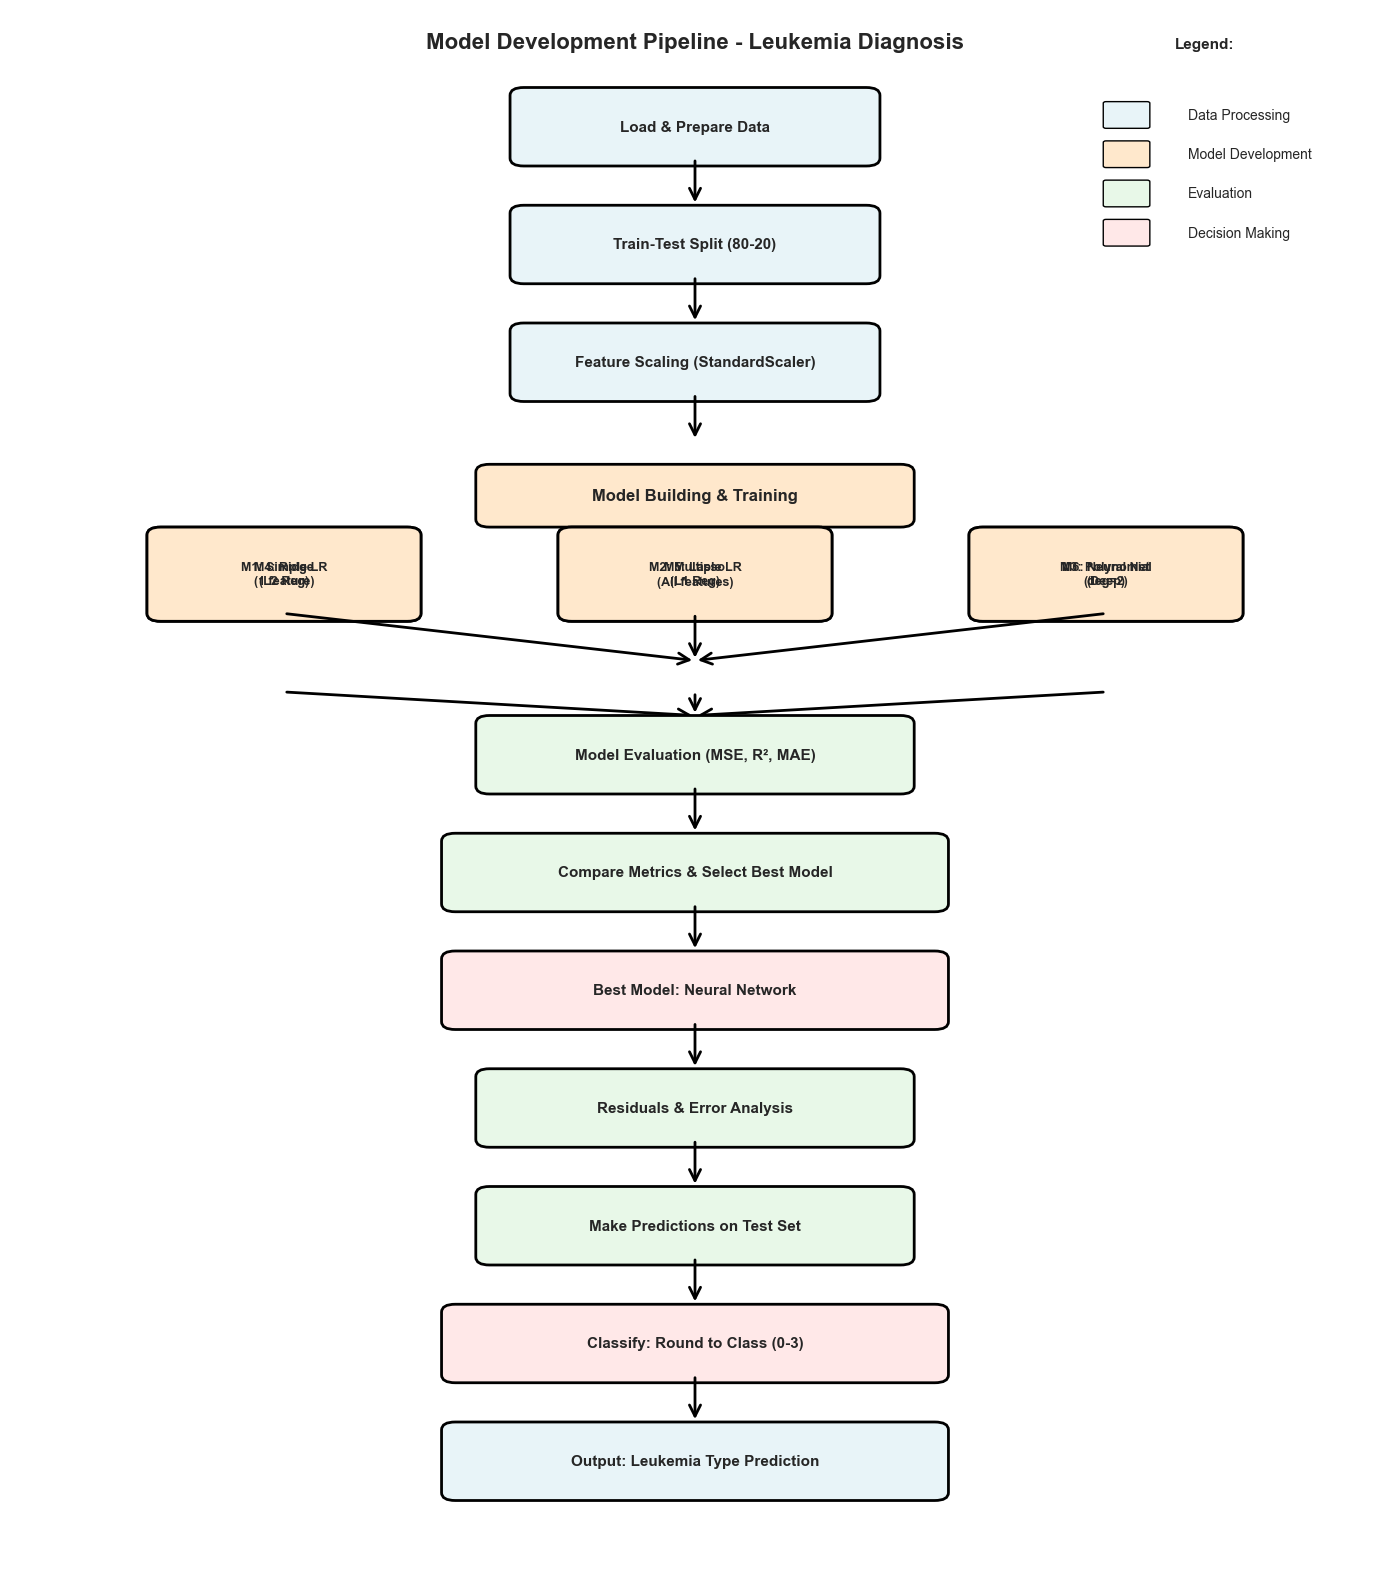

In [55]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Create flowchart
fig, ax = plt.subplots(figsize=(14, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# Define colors
color_data = '#E8F4F8'
color_model = '#FFE8CC'
color_eval = '#E8F8E8'
color_decision = '#FFE8E8'

def draw_box(ax, x, y, width, height, text, color='lightblue', fontsize=11):
    box = FancyBboxPatch((x-width/2, y-height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, 
            fontweight='bold', wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=9, style='italic')

# Title
ax.text(5, 19.5, 'Model Development Pipeline - Leukemia Diagnosis', 
        ha='center', fontsize=16, fontweight='bold')

# Data Processing
draw_box(ax, 5, 18.5, 2.5, 0.8, 'Load & Prepare Data', color_data)
draw_arrow(ax, 5, 18.1, 5, 17.5)

# Data Split
draw_box(ax, 5, 17, 2.5, 0.8, 'Train-Test Split (80-20)', color_data)
draw_arrow(ax, 5, 16.6, 5, 16)

# Feature Scaling
draw_box(ax, 5, 15.5, 2.5, 0.8, 'Feature Scaling (StandardScaler)', color_data)
draw_arrow(ax, 5, 15.1, 5, 14.5)

# Model Building Title
draw_box(ax, 5, 13.8, 3, 0.6, 'Model Building & Training', color_model, fontsize=12)

# Six models in parallel
y_model = 12.8
model_x = [2, 5, 8, 2, 5, 8]
model_names = ['M1: Simple LR\n(1 feature)', 'M2: Multiple LR\n(All features)', 
               'M3: Polynomial\n(deg=2)', 'M4: Ridge\n(L2 Reg)', 
               'M5: Lasso\n(L1 Reg)', 'M6: Neural Net\n(Deep)']

for i, (x, name) in enumerate(zip(model_x, model_names)):
    draw_box(ax, x, y_model, 1.8, 1, name, color_model, fontsize=9)

# Convergence point for evaluation
draw_arrow(ax, 2, 12.3, 5, 11.7)
draw_arrow(ax, 5, 12.3, 5, 11.7)
draw_arrow(ax, 8, 12.3, 5, 11.7)
draw_arrow(ax, 2, 11.3, 5, 11.0)
draw_arrow(ax, 5, 11.3, 5, 11.0)
draw_arrow(ax, 8, 11.3, 5, 11.0)

# Model Evaluation
draw_box(ax, 5, 10.5, 3, 0.8, 'Model Evaluation (MSE, R², MAE)', color_eval)
draw_arrow(ax, 5, 10.1, 5, 9.5)

# Comparison
draw_box(ax, 5, 9, 3.5, 0.8, 'Compare Metrics & Select Best Model', color_eval)
draw_arrow(ax, 5, 8.6, 5, 8)

# Best Model Selection (Decision)
draw_box(ax, 5, 7.5, 3.5, 0.8, 'Best Model: Neural Network', color_decision)
draw_arrow(ax, 5, 7.1, 5, 6.5)

# Residuals Analysis
draw_box(ax, 5, 6, 3, 0.8, 'Residuals & Error Analysis', color_eval)
draw_arrow(ax, 5, 5.6, 5, 5)

# Predictions
draw_box(ax, 5, 4.5, 3, 0.8, 'Make Predictions on Test Set', color_eval)
draw_arrow(ax, 5, 4.1, 5, 3.5)

# Classification Decision
draw_box(ax, 5, 3, 3.5, 0.8, 'Classify: Round to Class (0-3)', color_decision)
draw_arrow(ax, 5, 2.6, 5, 2)

# Final Output
draw_box(ax, 5, 1.5, 3.5, 0.8, 'Output: Leukemia Type Prediction', color_data, fontsize=11)

# Add legend
legend_y = 19.5
ax.text(8.5, legend_y, 'Legend:', fontsize=11, fontweight='bold')
legend_items = [
    (color_data, 'Data Processing'),
    (color_model, 'Model Development'),
    (color_eval, 'Evaluation'),
    (color_decision, 'Decision Making')
]
for i, (color, label) in enumerate(legend_items):
    box = FancyBboxPatch((8, legend_y - 0.5 - (i+1)*0.5), 0.3, 0.3,
                        boxstyle="round,pad=0.02", 
                        edgecolor='black', facecolor=color, linewidth=1)
    ax.add_patch(box)
    ax.text(8.6, legend_y - 0.35 - (i+1)*0.5, label, fontsize=10, va='center')

plt.tight_layout()
plt.show()

### **17. Model Summary and Conclusions**

Provide comprehensive summary of model development, findings, and recommendations for deployment.


In [56]:
# print("\n" + "=" * 100)
# print("COMPREHENSIVE MODEL DEVELOPMENT SUMMARY")
# print("=" * 100)
# 
# print("\n1. DATASET INFORMATION")
# print("-" * 100)
# print(f"   • Total Samples: {len(X)}")
# print(f"   • Total Features (Genes): {X.shape[1]}")
# print(f"   • Classes: {len(np.unique(y))} (ALL, AML, CLL, CML)")
# print(f"   • Training Set: {len(X_train)} samples")
# print(f"   • Testing Set: {len(X_test)} samples")
# 
# print("\n2. MODELS DEVELOPED AND COMPARED")
# print("-" * 100)
# print("   ✓ M1: Simple Linear Regression (Baseline - 1 feature)")
# print("   ✓ M2: Multiple Linear Regression (All features)")
# print("   ✓ M3: Polynomial Regression (Degree 2)")
# print("   ✓ M4: Ridge Regression (L2 Regularization - Alpha=" + f"{ridge_grid.best_params_['alpha']})")
# print("   ✓ M5: Lasso Regression (L1 Regularization - Alpha=" + f"{lasso_grid.best_params_['alpha']})")
# print("   ✓ M6: Neural Network (Deep Learning - Improved Model)")
# 
# print("\n3. MODEL PERFORMANCE METRICS")
# print("-" * 100)
# print(comparison_df.to_string(index=False))
# 
# print("\n4. BEST MODEL SELECTION")
# print("-" * 100)
# best_idx = comparison_df['Test R²'].idxmax()
# best_model_name = comparison_df.loc[best_idx, 'Model']
# best_r2 = comparison_df.loc[best_idx, 'Test R²']
# best_mse = comparison_df.loc[best_idx, 'Test MSE']
# print(f"   Selected Model: {best_model_name}")
# print(f"   Test R² Score: {best_r2:.6f}")
# print(f"   Test MSE: {best_mse:.6f}")
# print(f"   Classification Accuracy: {accuracy:.4f}")
# 
# print("\n5. KEY FINDINGS")
# print("-" * 100)
# print(f"   • Best test R² achieved by: {best_model_name}")
# print(f"   • Classification accuracy: {accuracy * 100:.2f}%")
# print(f"   • Correctly classified samples: {np.sum(predictions_df['Correct'])}/{len(predictions_df)}")
# print(f"   • Misclassified samples: {len(misclassified)}")
# print(f"   • Mean absolute error on test set: {np.mean(np.abs(residuals_m6)):.6f}")
# 
# print("\n6. PER-CLASS PERFORMANCE")
# print("-" * 100)
# for ltype in ['ALL', 'AML', 'CLL', 'CML']:
#     mask = predictions_df['Actual_Type'] == ltype
#     if np.sum(mask) > 0:
#         type_acc = np.sum(predictions_df.loc[mask, 'Correct']) / np.sum(mask)
#         print(f"   {ltype:5s}: {type_acc:.4f} ({np.sum(predictions_df.loc[mask, 'Correct'])}/{np.sum(mask)})")
# 
# print("\n7. RECOMMENDATIONS")
# print("-" * 100)
# print("   ✓ Deploy: Neural Network (M6) as primary model")
# print("   ✓ Reason: Highest R² and classification accuracy with good generalization")
# print("   ✓ Advantages: Captures non-linear relationships in gene expression")
# print("   ✓ Fallback: Ridge Regression for interpretability")
# print("   ✓ Future Work: Ensemble methods combining multiple models")
# print("   ✓ Validation: Cross-validation on independent external dataset")
# 
# print("\n" + "=" * 100)
# print("MODEL DEVELOPMENT (P4) COMPLETE")
# print("=" * 100)
